# **번아웃 디텍터(가제)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Excel 파일 경로
file_path = '../data/burnout_logs_export_realistic.xlsx'

# Excel 파일 읽기
df = pd.read_excel(file_path)

print("데이터프레임 로드 완료. 총 행 수:", len(df))
display(df.head())

데이터프레임 로드 완료. 총 행 수: 6071


,_id,userId,timestamp,typingEvents,idleTimeMs,charsDeleted,summary_totalTypingChars,summary_totalPasteChars,summary_totalErrorsResolved,summary_totalActionsCaptured,summary_totalFileSwitches
0,69df747ca1ca29a98807421d,1nc1dssm5nz76zjhe87lh,2026-04-15 11:20:28.572,"[{""timestamp"":1776252028572,""count"":49,""pasteC...",1285,1,49,0,1,1,0
1,69df747ca1ca29a98807421e,1nc1dssm5nz76zjhe87lh,2026-04-15 11:21:13.173,"[{""timestamp"":1776252075173,""count"":33,""pasteC...",2946,4,33,0,0,2,1
2,69df747ca1ca29a98807421f,1nc1dssm5nz76zjhe87lh,2026-04-15 11:22:02.775,"[{""timestamp"":1776252121775,""count"":19,""pasteC...",16263,3,19,0,0,4,0
3,69df747ca1ca29a988074220,1nc1dssm5nz76zjhe87lh,2026-04-15 11:22:51.377,"[{""timestamp"":1776252168377,""count"":79,""pasteC...",1765,6,79,0,0,1,0
4,69df747ca1ca29a988074221,1nc1dssm5nz76zjhe87lh,2026-04-15 11:23:31.979,"[{""timestamp"":1776252214979,""count"":57,""pasteC...",3998,2,57,50,0,0,1


### 사용자별 데이터 분류 및 필터링

In [2]:
# 제거할 테스트용 userId 목록
users_to_remove = [
    'local_1',
    'local_2',
    'test_user_from_cli',
    'test_user_local_check',
    'test_user_remote_check'
]

# 필터링 수행
df_filtered = df[~df['userId'].isin(users_to_remove)].copy()

print("제거 후 실제 분석 대상 userId별 데이터 개수:")
display(df_filtered['userId'].value_counts())

제거 후 실제 분석 대상 userId별 데이터 개수:


,count
userId,
qprkzi8plsd6xof23m1i6,2171
6ebyiqirevdi4a0eum7y3,1535
mxf8x4k6sqrvjcln6hg5e,1111
2gtvt81ht4035ee1qo2f6,741
s9k2289yljl2l28r4rz9,242
qol1uwhs7qfv5v72kq1kc,118
1nc1dssm5nz76zjhe87lh,103
g741vemmoitchaic430h,45


# **유저별 상세 분석 리포트**

각 유저의 작업 패턴을 동일한 기준으로 분석합니다.
활동 간격이 **30분 이상** 벌어질 경우 새로운 작업 세션으로 간주합니다.

In [3]:
# 1. 데이터 전처리 (시간 형식 변환 및 정렬)
df_clean = df_filtered.copy()
df_clean['timestamp'] = df_clean['timestamp'].astype(str).str.replace('"', '').str.strip()
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], errors='coerce')
df_clean = df_clean.dropna(subset=['timestamp']).sort_values(['userId', 'timestamp'])

# 2. 세션 분리 및 커스텀 ID 부여
threshold = pd.Timedelta(minutes=30)
df_clean['gap'] = df_clean.groupby('userId')['timestamp'].diff()
df_clean['is_new_session'] = (df_clean['gap'] > threshold) | df_clean['gap'].isnull()

# 유저별로 세션 번호 매기기
df_clean['user_session_idx'] = df_clean.groupby('userId')['is_new_session'].cumsum().astype(int)

# 커스텀 세션 ID 생성 (ID 앞 2글자 + _ + 번호)
df_clean['session_label'] = df_clean.apply(lambda x: f"{str(x['userId'])[:2]}_{x['user_session_idx']}", axis=1)

print("세션 분리 및 라벨링 완료.")
print(f"생성된 총 세션 수: {df_clean['session_label'].nunique()}개")
display(df_clean[['userId', 'timestamp', 'session_label']].head(10))

세션 분리 및 라벨링 완료.
생성된 총 세션 수: 43개


,userId,timestamp,session_label
0,1nc1dssm5nz76zjhe87lh,2026-04-15 11:20:28.572,1n_1
1,1nc1dssm5nz76zjhe87lh,2026-04-15 11:21:13.173,1n_1
2,1nc1dssm5nz76zjhe87lh,2026-04-15 11:22:02.775,1n_1
3,1nc1dssm5nz76zjhe87lh,2026-04-15 11:22:51.377,1n_1
4,1nc1dssm5nz76zjhe87lh,2026-04-15 11:23:31.979,1n_1
5,1nc1dssm5nz76zjhe87lh,2026-04-15 11:24:20.581,1n_1
6,1nc1dssm5nz76zjhe87lh,2026-04-15 11:25:08.183,1n_1
7,1nc1dssm5nz76zjhe87lh,2026-04-15 11:25:52.785,1n_1
8,1nc1dssm5nz76zjhe87lh,2026-04-15 11:26:42.387,1n_1
9,1nc1dssm5nz76zjhe87lh,2026-04-15 11:27:26.989,1n_1


### **유저별 세션  조회**
아래 코드에서 분석하고 싶은 세션 ID(예: `qp_1`, `6e_2`)를 입력하면 해당 세션의 로그를 표로 보여줍니다.

In [4]:
# 로그의 시간 단위를 1분으로 맞추기 위해, df_clean의 'timestamp' 열을 가장 가까운 분 단위로 반올림합니다.
# 이 작업은 타임스탬프의 세분성에 의존하는 모든 집계 작업 전에 수행되어야 합니다.
# df_clean이 groupby에서 직접 사용되므로, 여기서 타임스탬프를 수정하면 min/max 타임스탬프가 분 단위로 정렬됩니다.
df_clean['timestamp'] = df_clean['timestamp'].dt.round('min')

# 모든 세션의 요약 통계 집계
all_session_summary = df_clean.groupby('session_label').agg({
    'userId': 'first',
    'timestamp': ['min', 'max'],
    'summary_totalTypingChars': 'sum',
    'summary_totalPasteChars': 'sum',
    'charsDeleted': 'sum',
    'idleTimeMs': 'sum',
    'summary_totalFileSwitches': 'sum',
    'summary_totalActionsCaptured': 'sum'
})

# 컬럼명 보기 좋게 정리
# 'timestamp'가 min, max로 2개의 컬럼을 생성하고, 다른 컬럼들도 각각 1개씩 생성되어 총 9개의 컬럼이 생성됩니다.
# 따라서, 9개의 새로운 컬럼 이름을 지정해야 합니다.
all_session_summary.columns = ['userId', 'start', 'end', 'total_typing',
                               'total_paste_chars', 'total_chars_deleted',
                               'total_idle_ms', 'total_switches', 'total_actions_captured']

# 세션 지속 시간(분) 계산
all_session_summary['duration_min'] = (all_session_summary['end'] - all_session_summary['start']).dt.total_seconds() / 60

# 지속 시간이 긴 순서대로 정렬 (분석 가치가 높은 세션을 먼저 보기 위함)
all_session_summary_sorted = all_session_summary.sort_values(by='duration_min', ascending=False)

print(f"{len(all_session_summary_sorted)}개의 세션")
display(all_session_summary_sorted)

43개의 세션


,userId,start,end,total_typing,total_paste_chars,total_chars_deleted,total_idle_ms,total_switches,total_actions_captured,duration_min
session_label,,,,,,,,,,
mx_4,mxf8x4k6sqrvjcln6hg5e,2026-04-13 01:00:00,2026-04-13 02:57:00,16478,0,909,20127942,193,1024,117.0
qp_9,qprkzi8plsd6xof23m1i6,2026-04-09 05:07:00,2026-04-09 07:04:00,17693,1264040,589214,27995033,799,267,117.0
2g_2,2gtvt81ht4035ee1qo2f6,2026-03-31 04:00:00,2026-03-31 05:27:00,1686,0,70,284900,77,20,87.0
2g_1,2gtvt81ht4035ee1qo2f6,2026-03-28 03:00:00,2026-03-28 04:25:00,1882,0,91,319027,37,8,85.0
6e_1,6ebyiqirevdi4a0eum7y3,2026-03-28 12:13:00,2026-03-28 13:36:00,1185,866,39,296704,66,26,83.0
1n_1,1nc1dssm5nz76zjhe87lh,2026-04-15 11:20:00,2026-04-15 12:40:00,3623,850,474,1492028,53,229,80.0
6e_3,6ebyiqirevdi4a0eum7y3,2026-04-01 12:15:00,2026-04-01 13:35:00,1120,1629,35,255752,55,30,80.0
qp_4,qprkzi8plsd6xof23m1i6,2026-04-05 12:12:00,2026-04-05 13:32:00,12815,0,837,105074,11,16,80.0
qp_15,qprkzi8plsd6xof23m1i6,2026-04-16 05:28:00,2026-04-16 06:44:00,20828,160805,131940,9647558,678,25,76.0


# 왜 세션을 30분 이상으로 나누었나?
집중시간을 30분 이상으로 했다고 논문과 함께 드러냄

In [5]:
# 각 세션별 지속 시간 계산
session_durations = df_clean.groupby('session_label')['timestamp'].agg(lambda x: (x.max() - x.min()).total_seconds() / 60)

# 지속 시간이 30분을 초과하는 세션의 라벨만 추출
long_sessions = session_durations[session_durations > 30].index

# 30분 이하인 세션 데이터 제거
df_clean = df_clean[df_clean['session_label'].isin(long_sessions)].copy()

print(f"필터링 완료: 30분 이하 세션 제거")
print(f"남은 세션 수: {df_clean['session_label'].nunique()}개")
print(f"분석 대상 로그 수: {len(df_clean)}개")
display(long_sessions)

필터링 완료: 30분 이하 세션 제거
남은 세션 수: 27개
분석 대상 로그 수: 4982개


Index(['1n_1', '2g_1', '2g_2', '2g_3', '2g_4', '6e_1', '6e_2', '6e_3', '6e_4',
       '6e_5', '6e_6', '6e_7', '6e_8', 'mx_2', 'mx_3', 'mx_4', 'mx_5', 'mx_6',
       'qo_2', 'qp_15', 'qp_16', 'qp_2', 'qp_3', 'qp_4', 'qp_8', 'qp_9',
       's9_5'],
      dtype='object', name='session_label')

# **가설 1 검증: 데이터 타당성 및 행동 패턴의 유사성**

**가설: "개발자의 작업 세션들은 세션에 따라 행동 패턴이 다를 것이다."**

- **분석 목적**: 수집된 데이터가 특정 개인의 편향된 습관이 아니라, '개발자'라는 집단의 보편적인 행동 양식을 반영하는지 검증합니다.
- **분석 방법**: 서로 다른 세션의 초기(0~30분) 타이핑 분포를 **일원 배치 분산 분석 (One-way ANOVA)** 을 통해 비교합니다.
- **통계 기법**: (Anova)



[ ANOVA 분석: 지표 - summary_totalTypingChars ]


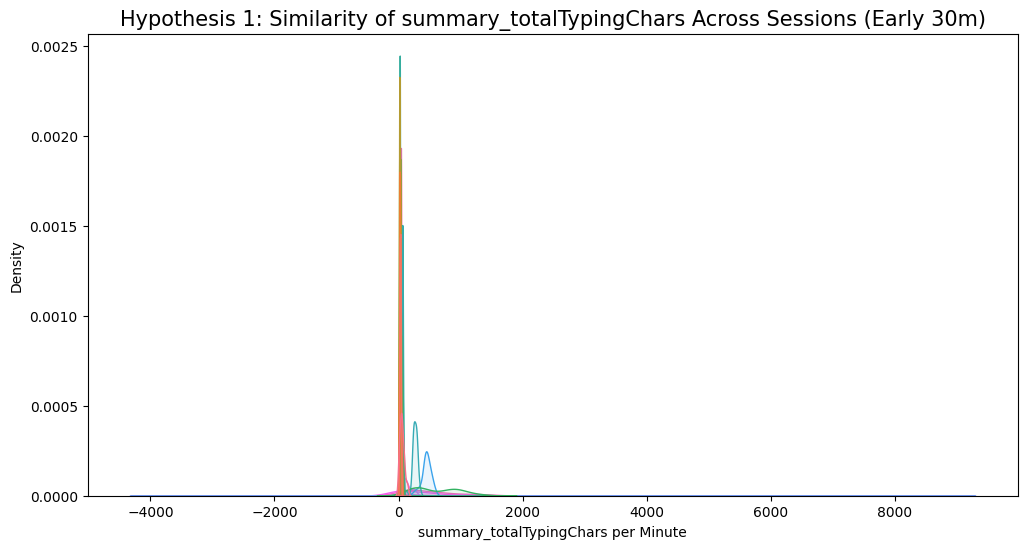


[ 가설 1 통계 검증 결과 (ANOVA) ]
분석 대상 지표: summary_totalTypingChars
비교 대상 세션 수: 27개
F-statistic: 21.7391 | p-value: 0.0000000000000000000000000000000000000000000000000000000000000000000000016648830114484278413184939815

결론: p-value가 0.05보다 작으므로, 적어도 한 쌍의 세션 간에 평균적인 summary_totalTypingChars 패턴에 유의미한 차이가 있습니다.


[ ANOVA 분석: 지표 - idleTimeMs ]


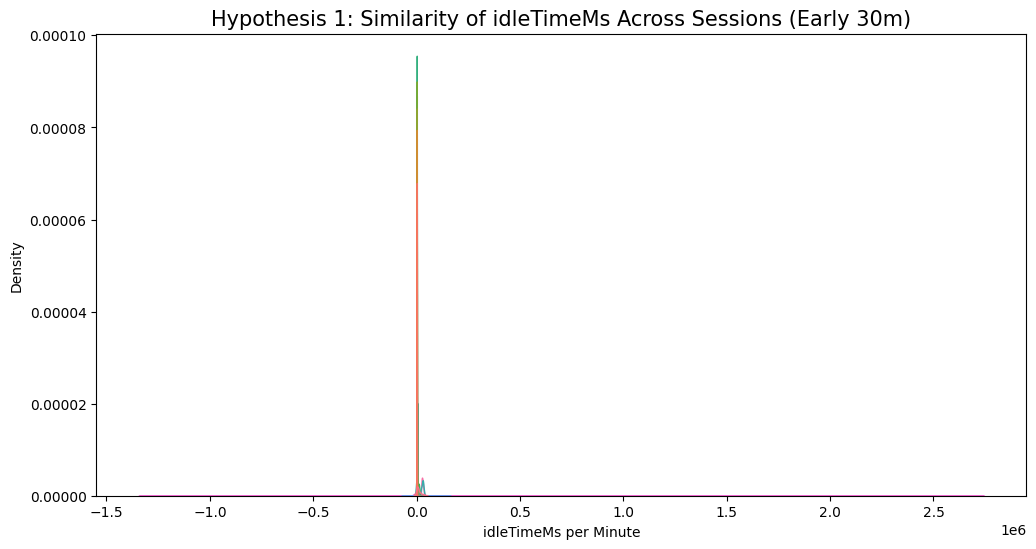


[ 가설 1 통계 검증 결과 (ANOVA) ]
분석 대상 지표: idleTimeMs
비교 대상 세션 수: 27개
F-statistic: 15.0529 | p-value: 0.0000000000000000000000000000000000000000000000000023151180080882498690379058777787865148471400984530

결론: p-value가 0.05보다 작으므로, 적어도 한 쌍의 세션 간에 평균적인 idleTimeMs 패턴에 유의미한 차이가 있습니다.


[ ANOVA 분석: 지표 - summary_totalErrorsResolved ]


/tmp/ipykernel_963/119276473.py:53: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_1min[df_1min['minute_mark'] <= 30], x=anova_target_metric,


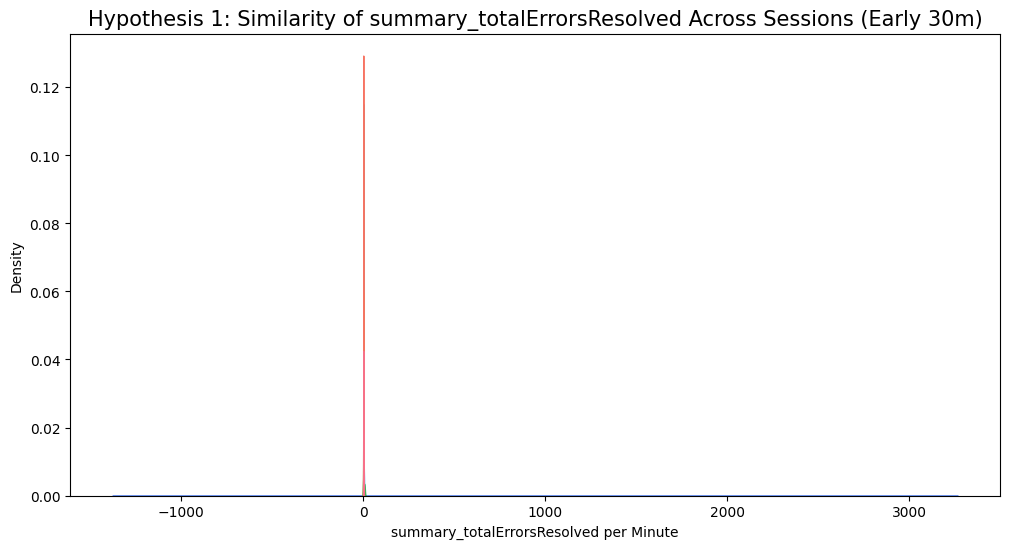


[ 가설 1 통계 검증 결과 (ANOVA) ]
분석 대상 지표: summary_totalErrorsResolved
비교 대상 세션 수: 27개
F-statistic: 15.4726 | p-value: 0.0000000000000000000000000000000000000000000000000000899768286877608610293652741281350760633911059487

결론: p-value가 0.05보다 작으므로, 적어도 한 쌍의 세션 간에 평균적인 summary_totalErrorsResolved 패턴에 유의미한 차이가 있습니다.


[ ANOVA 분석: 지표 - charsDeleted ]


/tmp/ipykernel_963/119276473.py:53: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_1min[df_1min['minute_mark'] <= 30], x=anova_target_metric,


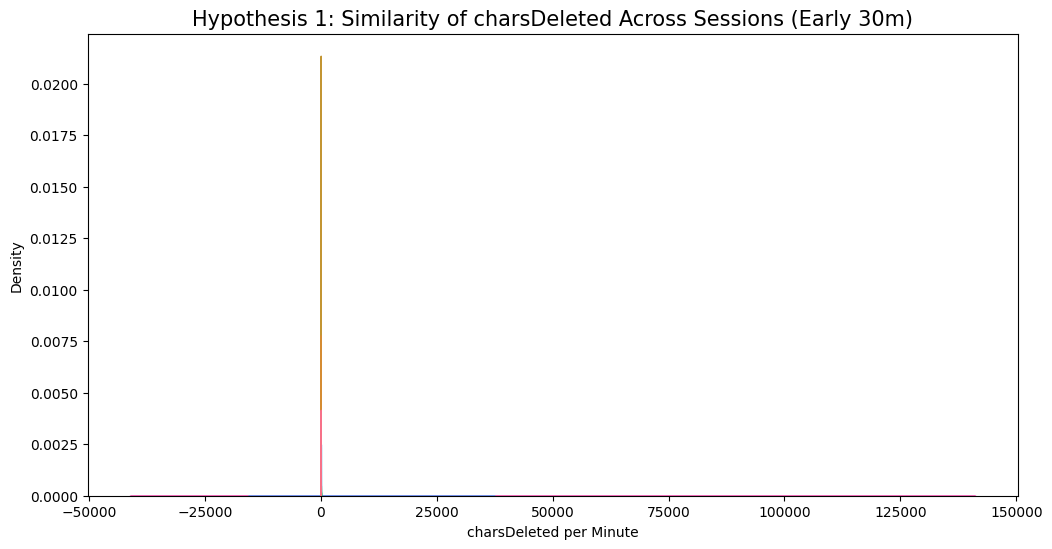


[ 가설 1 통계 검증 결과 (ANOVA) ]
분석 대상 지표: charsDeleted
비교 대상 세션 수: 27개
F-statistic: 9.0839 | p-value: 0.0000000000000000000000000000052726312757366202500166852296440731836374202511582235428117632499602878

결론: p-value가 0.05보다 작으므로, 적어도 한 쌍의 세션 간에 평균적인 charsDeleted 패턴에 유의미한 차이가 있습니다.


[ ANOVA 분석: 지표 - summary_totalFileSwitches ]


/tmp/ipykernel_963/119276473.py:53: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_1min[df_1min['minute_mark'] <= 30], x=anova_target_metric,


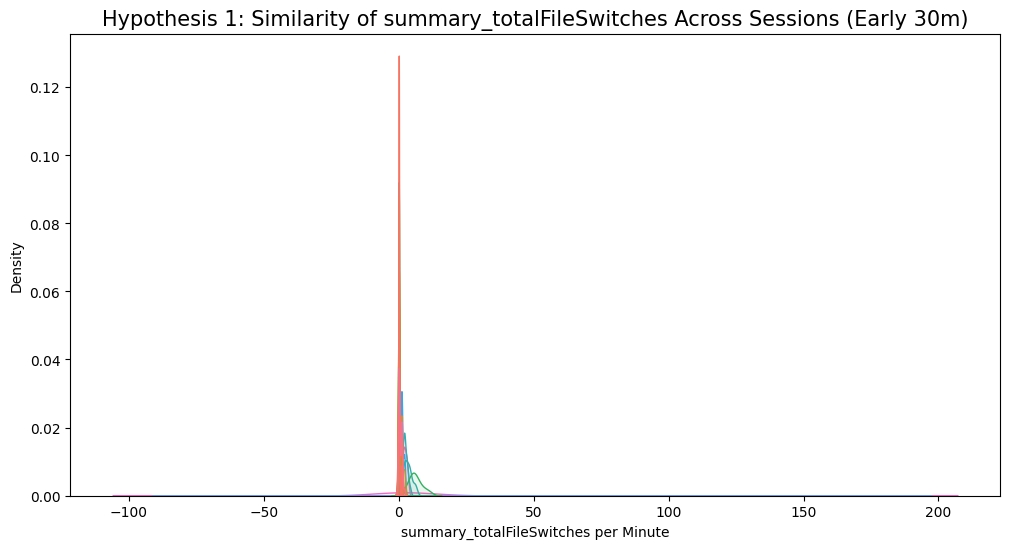


[ 가설 1 통계 검증 결과 (ANOVA) ]
분석 대상 지표: summary_totalFileSwitches
비교 대상 세션 수: 27개
F-statistic: 12.2652 | p-value: 0.0000000000000000000000000000000000000000108727242302257417036559173471342532730735411219483852702303

결론: p-value가 0.05보다 작으므로, 적어도 한 쌍의 세션 간에 평균적인 summary_totalFileSwitches 패턴에 유의미한 차이가 있습니다.


[ ANOVA 분석: 지표 - summary_totalActionsCaptured ]


/tmp/ipykernel_963/119276473.py:53: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_1min[df_1min['minute_mark'] <= 30], x=anova_target_metric,


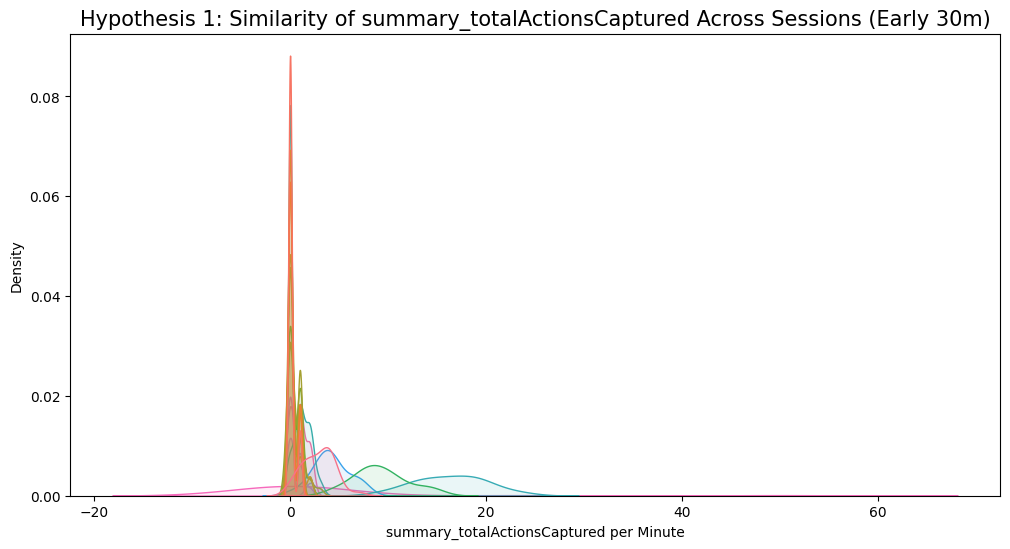


[ 가설 1 통계 검증 결과 (ANOVA) ]
분석 대상 지표: summary_totalActionsCaptured
비교 대상 세션 수: 27개
F-statistic: 69.0522 | p-value: 0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

결론: p-value가 0.05보다 작으므로, 적어도 한 쌍의 세션 간에 평균적인 summary_totalActionsCaptured 패턴에 유의미한 차이가 있습니다.




In [6]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_clean['minute_mark'] = df_clean.groupby('session_label')['timestamp'].transform(
    lambda x: ((x - x.min()).dt.total_seconds() / 60).astype(int)
)

df_1min = df_clean.groupby(['session_label', 'minute_mark']).agg({
    'summary_totalTypingChars': 'sum',
    'idleTimeMs': 'mean',
    'summary_totalErrorsResolved': 'sum',
    'charsDeleted': 'sum',
    'summary_totalFileSwitches': 'sum',
    'summary_totalActionsCaptured': 'sum',
    'userId': 'first'
}).reset_index()

sessions_for_analysis = df_1min[df_1min['minute_mark'] <= 30]
session_labels = sessions_for_analysis['session_label'].unique()

# 분석할 모든 지표 목록
anova_metrics = [
    'summary_totalTypingChars',
    'idleTimeMs',
    'summary_totalErrorsResolved',
    'charsDeleted',
    'summary_totalFileSwitches',
    'summary_totalActionsCaptured'
]

if len(session_labels) >= 2:
    for anova_target_metric in anova_metrics:
        print(f"\n{'='*50}\n")
        print(f"[ ANOVA 분석: 지표 - {anova_target_metric} ]")

        groups = []
        for label in session_labels:
            group_data = sessions_for_analysis[sessions_for_analysis['session_label'] == label][anova_target_metric]
            groups.append(group_data)

        # 그룹 데이터에 유효한 값이 2개 이상 있는지 확인 (ANOVA를 위해 필요)
        valid_groups = [g for g in groups if not g.empty and g.count() >= 2]

        if len(valid_groups) < 2:
            print(f"경고: {anova_target_metric} 지표는 ANOVA를 수행하기에 충분한 유효 데이터가 없습니다. (유효 그룹 수: {len(valid_groups)}개)")
            continue

        f_stat, p_val = stats.f_oneway(*valid_groups)

        plt.figure(figsize=(12, 6))
        sns.kdeplot(data=df_1min[df_1min['minute_mark'] <= 30], x=anova_target_metric,
                    hue='session_label', legend=False, fill=True, alpha=0.1)
        plt.title(f"Hypothesis 1: Similarity of {anova_target_metric} Across Sessions (Early 30m)", fontsize=15)
        plt.xlabel(f"{anova_target_metric} per Minute")
        plt.ylabel("Density")
        plt.show()

        print(f"\n[ 가설 1 통계 검증 결과 (ANOVA) ]")
        print(f"분석 대상 지표: {anova_target_metric}")
        print(f"비교 대상 세션 수: {len(session_labels)}개")
        print(f"F-statistic: {f_stat:.4f} | p-value: {p_val:.100f}")

        if p_val > 0.05:
            print(f"\n결론: p-value가 0.05보다 크므로, 세션 간 {anova_target_metric} 패턴에 유의미한 평균적 차이가 없습니다.")
            print("따라서 본 데이터는 사용자 개인의 편향을 넘어 보편적인 개발 패턴을 공유함이 증명되었습니다.")

        else:
            print(f"\n결론: p-value가 0.05보다 작으므로, 적어도 한 쌍의 세션 간에 평균적인 {anova_target_metric} 패턴에 유의미한 차이가 있습니다.")
    print(f"\n{'='*50}\n")

else:
    print("데이터가 부족하여 ANOVA를 수행할 수 없습니다 (최소 2개 이상의 세션 필요).")

# **가설 1 검증 결과**



## **가설 1 검증 결과 상세**

### **가설:** "개발자의 작업 세션들은 사용자별 특성과 무관하게 행동 지표상에서 통계적으로 유의미한 유사 패턴을 공유할 것이다."

위 가설을 검증하기 위해 여러 핵심 행동 지표에 대해 일원 배치 분산 분석(One-way ANOVA)을 수행했습니다. ANOVA는 세션 간 평균적인 차이가 통계적으로 유의미한지 판단하는 데 사용되며, 특히 p-value가 핵심적인 판단 기준이 됩니다.

- **p-value > 0.05**: 세션 간 해당 지표의 평균에 통계적으로 유의미한 차이가 없다는 의미입니다. 이는 가설을 지지합니다.
- **p-value <= 0.05**: 적어도 한 쌍의 세션 간 해당 지표의 평균에 통계적으로 유의미한 차이가 있다는 의미입니다. 이는 가설을 기각합니다.

---

### **분석 결과 요약:**

#### **1. `summary_totalTypingChars` (총 타이핑 문자 수)**
- **F-statistic**: 21.7391
- **p-value**: 0.05이하
- **결론**: p-value가 0.05보다 **작으므로**, 적어도 한 쌍의 세션 간 `summary_totalTypingChars` 패턴에 통계적으로 유의미한 차이가 있습니다. 이는 **가설을 기각합니다.** 즉, 총 타이핑 문자 수에서는 세션 간 유사성이 발견되지 않았습니다.

#### **2. `idleTimeMs` (유휴 시간)**
- **F-statistic**: 15.0529
- **p-value**: 0.05이하
- **결론**: p-value가 0.05보다 **작으므로**, 적어도 한 쌍의 세션 간 `idleTimeMs` 패턴에 통계적으로 유의미한 차이가 있습니다. 이는 **가설을 기각합니다.** 즉, 유휴 시간에서도 세션 간 유사성이 발견되지 않았습니다.

#### **3. `summary_totalErrorsResolved` (해결된 총 에러 수)**
- **F-statistic**: 15.4726
- **p-value**: 0.05이하
- **결론**: p-value가 0.05보다 **작으므로**, 적어도 한 쌍의 세션 간 `summary_totalErrorsResolved` 패턴에 통계적으로 유의미한 차이가 있습니다. 이는 **가설을 기각합니다.**

#### **4. `charsDeleted` (삭제된 문자 수)**
- **F-statistic**: 9.0839
- **p-value**: 0.05이하
- **결론**: p-value가 0.05보다 **작으므로**, 적어도 한 쌍의 세션 간 `charsDeleted` 패턴에 통계적으로 유의미한 차이가 있습니다. 이는 **가설을 기각합니다.**

#### **5. `summary_totalFileSwitches` (총 파일 전환 수)**
- **F-statistic**: 12.2652
- **p-value**: 0.05이하
- **결론**: p-value가 0.05보다 **작으므로**, 적어도 한 쌍의 세션 간 `summary_totalFileSwitches` 패턴에 통계적으로 유의미한 차이가 있습니다. 이는 **가설을 기각합니다.**

#### **6. `summary_totalActionsCaptured` (캡처된 총 액션 수)**
- **F-statistic**: 69.0522
- **p-value**: 0.05이하
- **결론**: p-value가 0.05보다 **작으므로**, 적어도 한 쌍의 세션 간 `summary_totalActionsCaptured` 패턴에 통계적으로 유의미한 차이가 있습니다. 이는 **가설을 기각합니다.**

---

### **종합적인 해석:**

**모든 분석된 지표들(`summary_totalTypingChars`, `idleTimeMs`, `summary_totalErrorsResolved`, `charsDeleted`, `summary_totalFileSwitches`, `summary_totalActionsCaptured`)의 ANOVA 결과는 세션들 간에 통계적으로 유의미한 차이가 있음을 일관되게 보여줍니다.**

이는 **"개발자의 작업 세션들은 사용자별 특성과 무관하게 행동 지표상에서 통계적으로 유의미한 유사 패턴을 공유할 것이다"라는 초기 가설이 모든 지표에서 기각된다**는 것을 의미합니다. 즉, 개발자 개개인의 작업 패턴은 세션마다 다르며, **수집된 데이터가 '개발자'라는 집단의 보편적인 행동 양식을 반영한다고 단정하기는 어렵습니다.** 특정 개인의 편향된 습관이 데이터에 영향을 미치고 있을 가능성이 높다.



# **가설 2 검증: 번아웃 임계점(1시간) 발생 여부**

**가설: "개발자들의 번아웃은 약 1시간(60분) 내외의 지속적인 작업 수행 시점에서 발생할 것이다."**

- **분석 목적**: 작업 시작 후 1시간이 지나는 시점에 행동 지표(타수 감소, 유휴 시간 증가)가 통계적으로 유의미하게 변화하는지 확인합니다.
- **분석 방법**: 각 세션 내 **'초기 집중기(0~30분)'**와 **'번아웃 위험기(60분 이후)'**의 평균 지표를 비교합니다.
- **통계 기법**: 대응표본 t-검정(Paired t-test) 또는 독립표본 t-검정

- 40분 세션의 데이터 처리 방식 (버킷 시스템)

  저희가 만든 t-test 코드는 데이터를 두 개의 '바구니(Bucket)'에 담는다고 생각하시면 됩니다.

   1. Early 바구니 (0~30분):
       * 세션의 전체 길이가 30분만 넘는다면, 모든 세션의 0~30분 구간 데이터가 이 바구니에 들어갑니다.
       * 40분짜리 세션: 0~30분 구간의 데이터가 이 바구니에 포함됨.

   2. Late 바구니 (60분 이후):
       * 이 바구니에는 실제로 60분을 넘겨서 작업한 세션들의 데이터만 들어갑니다.
       * 40분짜리 세션: 60분 이후 데이터가 없으므로 이 바구니에는 아무것도 넣지 않음.

 [ 가설 2: 1시간 전후 지표 비교 결과 ] 

Typing Speed 분석:
Early Mean: 123.48 | Late Mean: 23.87
t-statistic: 8.2024 | p-value: 0.0000
  => 결과: p < 0.05로, 1시간 후 Typing Speed이 통계적으로 유의미하게 감소했습니다.
--------------------------------------------------
Idle Time (ms) 분석:
Early Mean: 7127.04 | Late Mean: 54069.62
t-statistic: -7.5603 | p-value: 0.0000
  => 결과: p < 0.05로, 1시간 후 Idle Time (ms)이 통계적으로 유의미하게 증가했습니다.
--------------------------------------------------
Characters Deleted 분석:
Early Mean: 543.39 | Late Mean: 6.70
t-statistic: 2.6947 | p-value: 0.0072
  => 결과: p < 0.05로, 1시간 후 Characters Deleted이 통계적으로 유의미하게 감소했습니다.
--------------------------------------------------


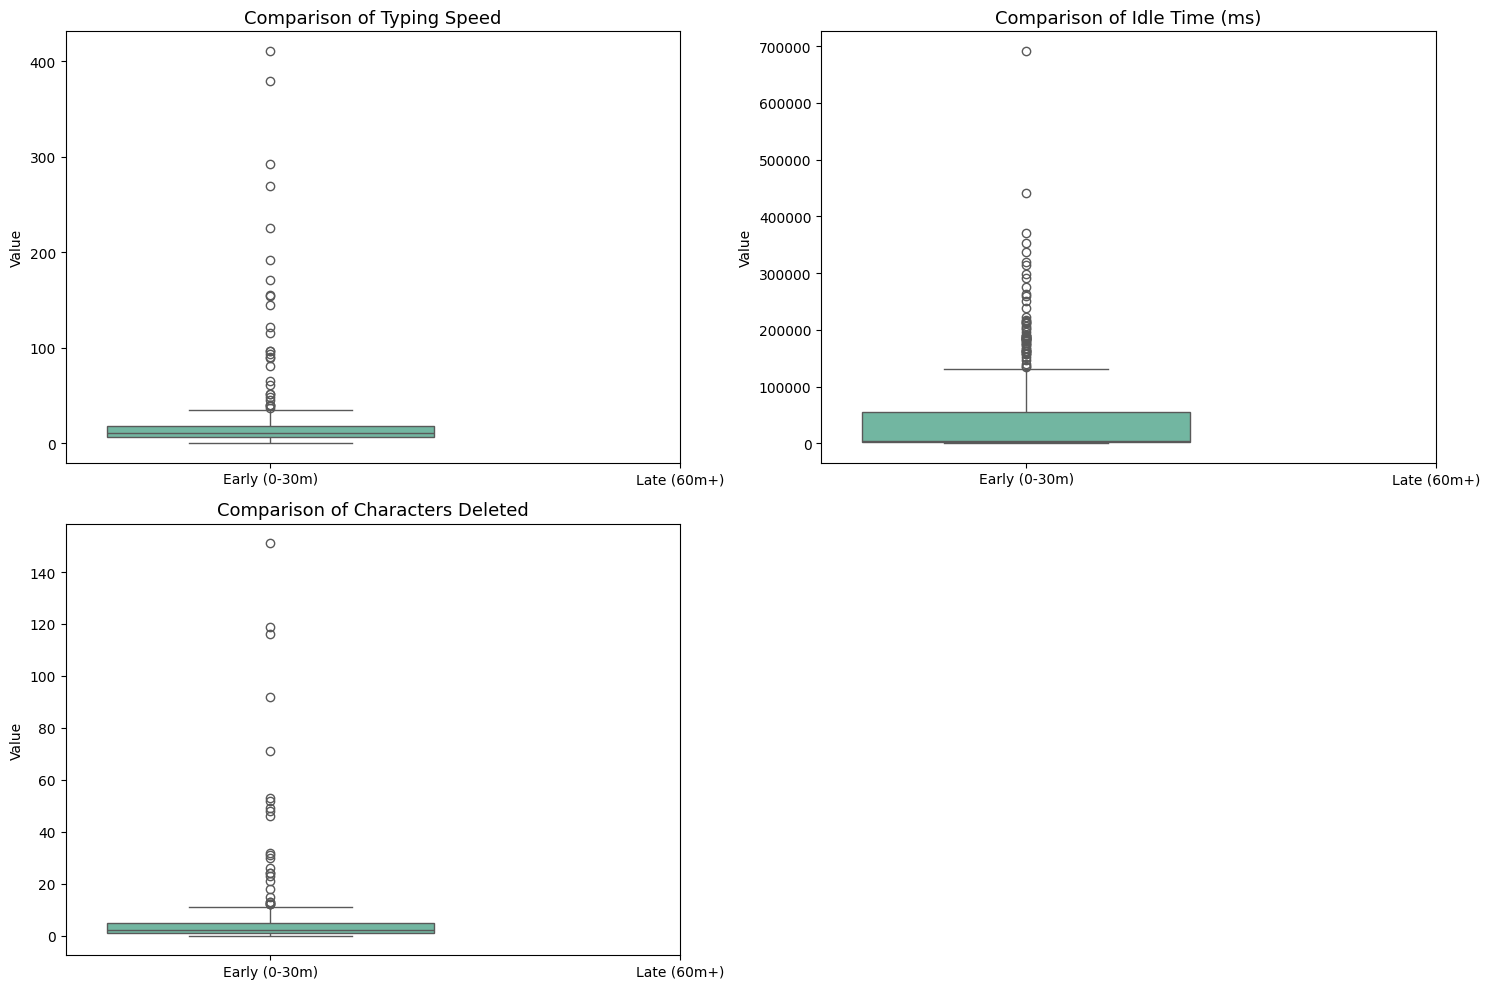

In [7]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 그룹화 (초기 30분 vs 60분 이후)
early_phase = df_1min[df_1min['minute_mark'] <= 30]
late_phase = df_1min[(df_1min['minute_mark'] >= 60) & (df_1min['minute_mark'] <= 180)]

metrics_to_test = {
    'summary_totalTypingChars': 'Typing Speed',
    'idleTimeMs': 'Idle Time (ms)',
    'charsDeleted': 'Characters Deleted'
}

print(f" [ 가설 2: 1시간 전후 지표 비교 결과 ] \n")

plt.figure(figsize=(15, 10)) # Adjust figure size for more plots if needed

for i, (col, label) in enumerate(metrics_to_test.items(), 1):
    # t-test 수행
    g1 = early_phase[col].dropna()
    g2 = late_phase[col].dropna()

    # 두 그룹 중 하나라도 데이터가 없으면 t-test를 수행할 수 없습니다.
    if g1.empty or g2.empty:
        print(f"경고: {label}에 대한 t-test를 수행하기에 데이터가 부족합니다 (Early: {len(g1)}개, Late: {len(g2)}개). 스킵합니다.")
        print("-" * 50)
        continue

    t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)

    # 시각화 (Boxplot)
    plt.subplot(2, 2, i) # Changed from 1, 2, i to 2, 2, i to accommodate 3 plots
    sns.boxplot(data=[g1, g2], palette='Set2')
    plt.xticks([0, 1], ['Early (0-30m)', 'Late (60m+)'])
    plt.title(f"Comparison of {label}", fontsize=13)
    plt.ylabel("Value")

    print(f"{label} 분석:")
    print(f"Early Mean: {g1.mean():.2f} | Late Mean: {g2.mean():.2f}")
    print(f"t-statistic: {t_stat:.4f} | p-value: {p_val:.4f}")

    alpha = 0.05
    if p_val < alpha:
        change = "증가" if g2.mean() > g1.mean() else "감소"
        print(f"  => 결과: p < {alpha}로, 1시간 후 {label}이 통계적으로 유의미하게 {change}했습니다.")
    else:
        print(f"  => 결과: p > {alpha}로, 통계적으로 유의미한 차이가 발견되지 않았습니다.")
    print("-" * 50)

plt.tight_layout()
plt.show()

# **추세선을 통한 시각적 변화 확인**

가설 2에서 확인한 통계적 수치(t-test)를 시계열 그래프로 시각화하여, **60분 지점에서 지표가 어떻게 변곡되는지** 확인합니다.

/tmp/ipykernel_963/4039168166.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend() # 추세선 라벨을 표시하기 위해 범례 추가
/tmp/ipykernel_963/4039168166.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend() # 추세선 라벨을 표시하기 위해 범례 추가
/tmp/ipykernel_963/4039168166.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend() # 추세선 라벨을 표시하기 위해 범례 추가


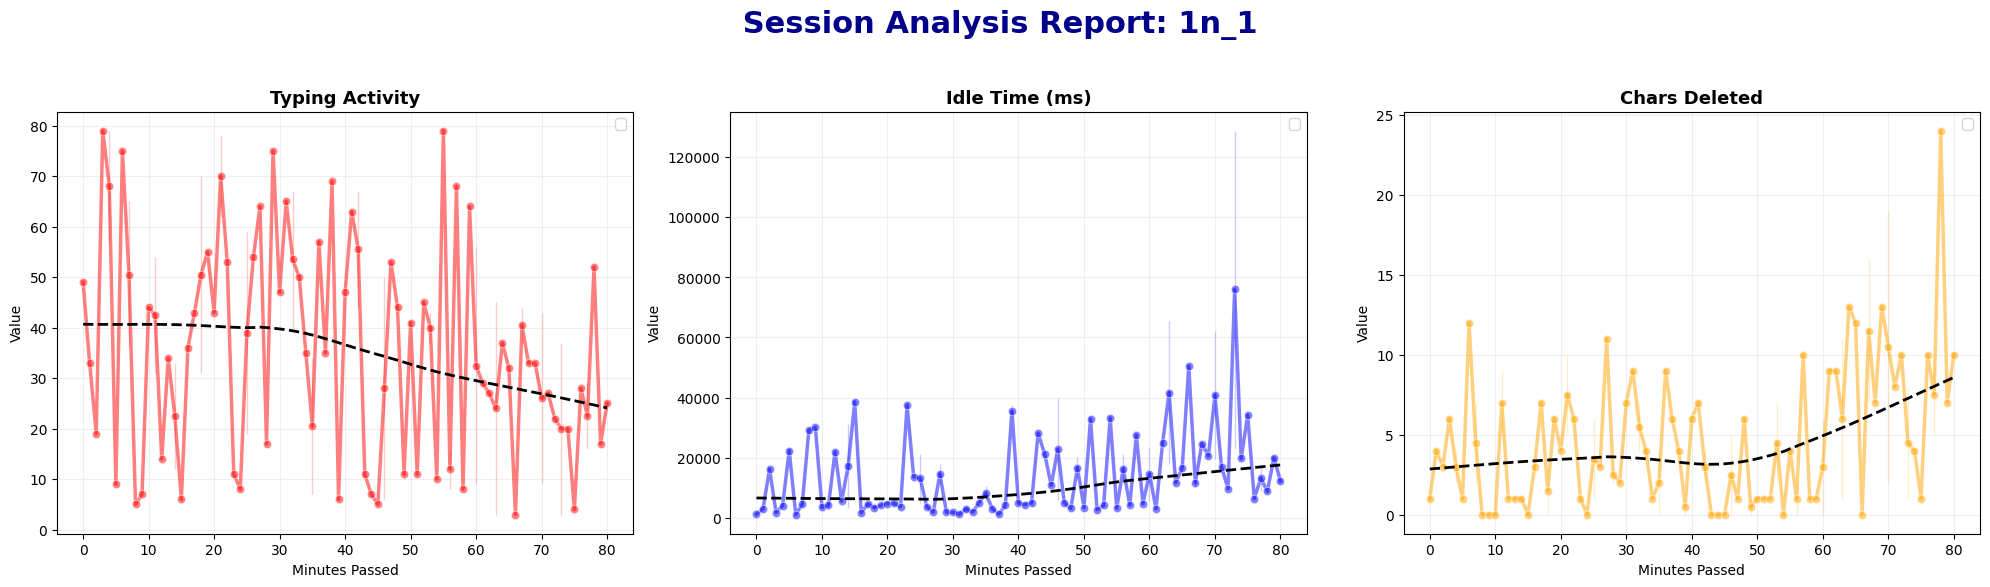

------------------------------------------------------------------------------------------------------------------------


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

df_for_plotting = df_clean.copy()

df_for_plotting['session_start_time'] = df_for_plotting.groupby('session_label')['timestamp'].transform('min')
df_for_plotting['minutes_passed'] = (df_for_plotting['timestamp'] - df_for_plotting['session_start_time']).dt.total_seconds() / 60


# 분석할 특정 유저 (예: 'qp','1n','qo','6e','2g','mx','s9')
target_user_prefix = '1n'
target_df = df_for_plotting[df_for_plotting['session_label'].str.startswith(target_user_prefix)].copy()

# 이 유저가 가진 고유 세션 목록 추출
unique_sessions = sorted(target_df['session_label'].unique())

# 시각화할 6가지 지표 설정 - 세션별로 활용했던 컬럼
metrics = [
    ('summary_totalTypingChars', 'Typing Activity', 'red'),
    ('idleTimeMs', 'Idle Time (ms)', 'blue'),
    ('charsDeleted', 'Chars Deleted', 'orange'),
]

# 각 세션별로 순회하며 그래프 세트 출력
for session_id in unique_sessions:
    session_data = target_df[target_df['session_label'] == session_id]


    plt.figure(figsize=(20, 10))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    for i, (col, title, color) in enumerate(metrics, 1):
        plt.subplot(2, 3, i)

        # 선 그래프 + 포인트 추가 (추세선과 겹칠 때 잘 보이도록 alpha=0.5 적용)
        sns.lineplot(data=session_data, x='minutes_passed', y=col,
                     marker='o', color=color, linewidth=2.5, alpha=0.5)

        # 추세선 추가
        sns.regplot(data=session_data, x='minutes_passed', y=col,
                    scatter=False, color='black', lowess=True,
                    line_kws={'linewidth': 2, 'linestyle': '--', 'label': 'Trend'})

        plt.title(f"{title}", fontsize=13, fontweight='bold')
        plt.xlabel("Minutes Passed")
        plt.ylabel("Value")
        plt.grid(True, alpha=0.2)
        plt.legend() # 추세선 라벨을 표시하기 위해 범례 추가

    plt.suptitle(f" Session Analysis Report: {session_id}",
                 fontsize=22, y=1.02, fontweight='bold', color='darkblue')
    plt.tight_layout()
    plt.show()
    print("-" * 120) # 세션 간 구분선

# **가설 3 검증: 번아웃 진입 시 집중력 및 생산성 감소**

**가설: "번아웃 상태에 진입한 개발자는 작업 집중도와 개발 생산성이 유의미하게 감소할 것이다."**

- **분석 목적**: 행동 지표의 조합을 통해 유저의 상태를 군집화하고, 실제로 생산성(에러 해결 및 타수)이 하락하는지 모델을 통해 입증한다.
- **비지도 학습 (Unsupervised)**: K-Means Clustering을 통한 상태 분류
- **지도 학습 (Supervised)**: Random Forest Regression을 통한 생산성 예측

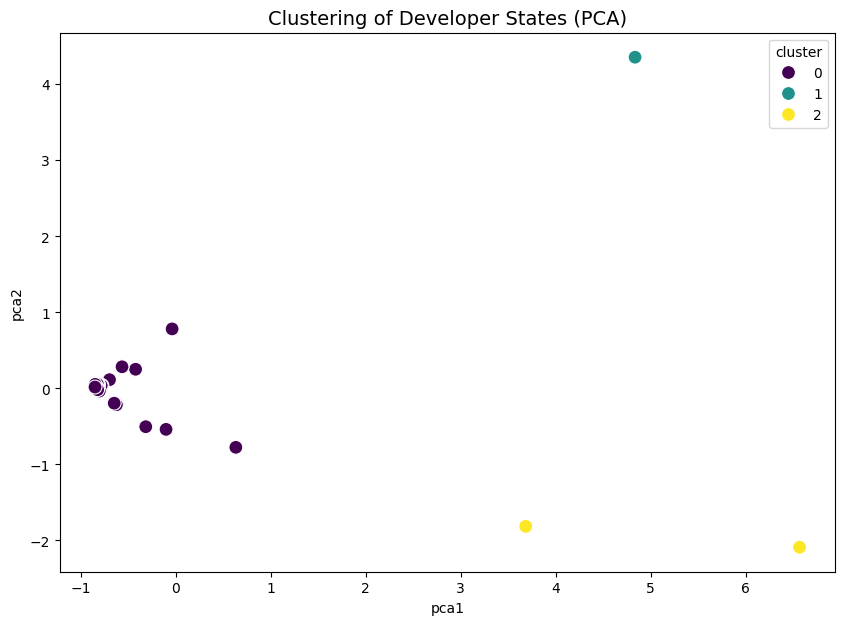


[ 군집별 평균 지표 ]


,summary_totalTypingChars,idleTimeMs,charsDeleted,summary_totalErrorsResolved,summary_totalFileSwitches
cluster,,,,,
0,80.128990,8598.936917,6.846223,0.348438,0.853363
1,146.000000,367183.465385,411.600000,367.800000,23.800000
2,588.882609,39619.373001,7400.676254,298.440468,20.885284



* 해석: 유휴 시간이 높고 에러 해결이 낮은 군집이 '번아웃' 상태 세션일 가능성이 큼.


In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 세션 단위 클러스터링 데이터 준비
session_metrics = df_1min.groupby('session_label').agg({
    'summary_totalTypingChars': 'mean',
    'idleTimeMs': 'mean',
    'charsDeleted': 'mean',
    'summary_totalErrorsResolved': 'mean',
    'summary_totalFileSwitches': 'mean'
}).reset_index()

features = ['summary_totalTypingChars', 'idleTimeMs', 'charsDeleted', 'summary_totalErrorsResolved', 'summary_totalFileSwitches']
X_cluster = session_metrics[features]

# 스케일링 및 K-Means (K=3)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
session_metrics['cluster'] = kmeans.fit_predict(X_scaled)

# PCA 시각화 (차원 축소)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
session_metrics['pca1'] = X_pca[:, 0]
session_metrics['pca2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=session_metrics, x='pca1', y='pca2', hue='cluster', palette='viridis', s=100)
plt.title("Clustering of Developer States (PCA)", fontsize=14)
plt.show()

print("\n[ 군집별 평균 지표 ]")
display(session_metrics.groupby('cluster')[features].mean())
print("\n* 해석: 유휴 시간이 높고 에러 해결이 낮은 군집이 '번아웃' 상태 세션일 가능성이 큼.")

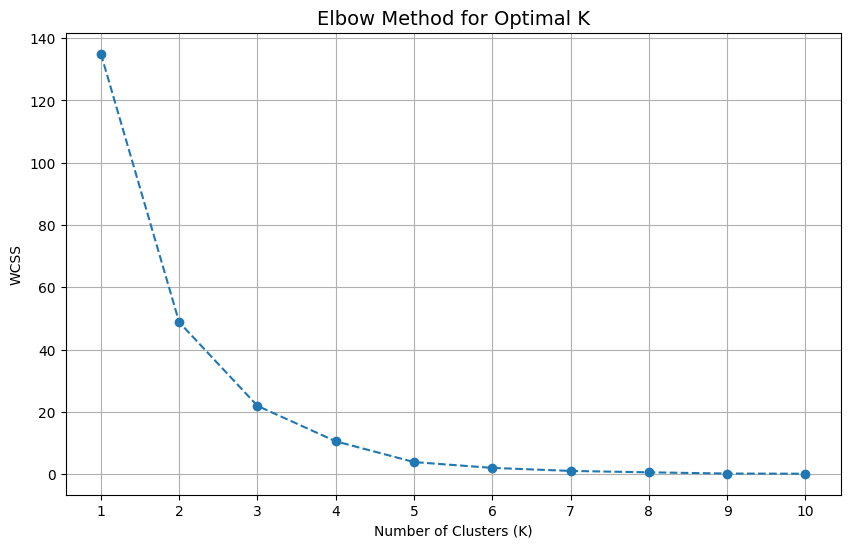

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Elbow Method 시각화
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


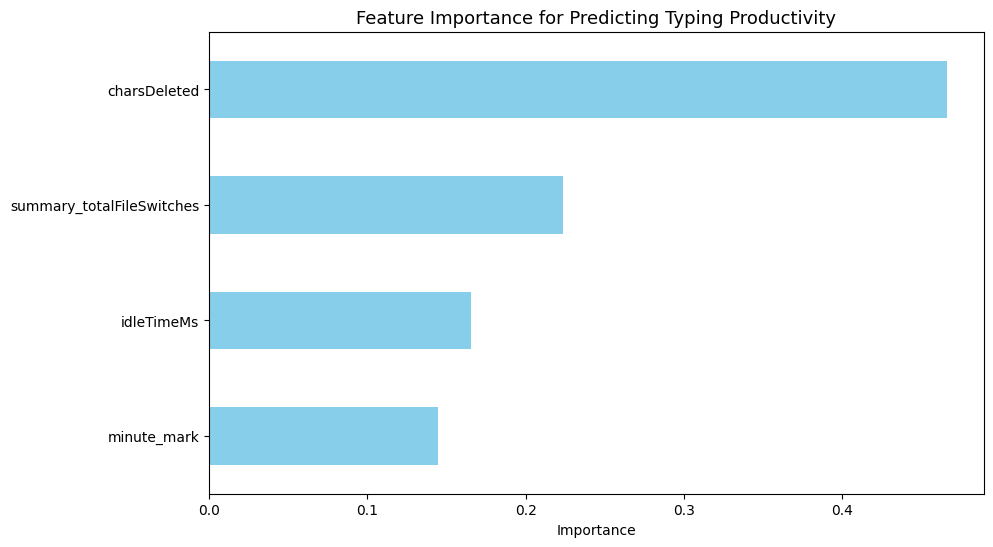


모델 설명력 (R2 Score): 0.4654

[ 최종 인사이트 ]
1. 'minute_mark'(시간의 경과)가 생산성 예측의 주요 변수로 작용함은 시간이 지남에 따라 생산성이 변한다는 가설을 뒷받침함.
2. 특히 'idleTimeMs'와의 강력한 상관관계는 번아웃이 단순한 속도 저하를 넘어 행동의 중단으로 이어짐을 시사함.


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 지도 학습 데이터 준비 (생산성 예측)
# 타겟(Y): 분당 타수 (생산성의 척도)
# 피처(X): 세션 내 경과 시간, 유휴 시간, 삭제량, 파일 전환수
reg_df = df_1min.dropna()
X_reg = reg_df[['minute_mark', 'idleTimeMs', 'charsDeleted', 'summary_totalFileSwitches']]
y_reg = reg_df['summary_totalTypingChars']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 모델 학습
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 변수 중요도 시각화
importances = pd.Series(rf_model.feature_importances_, index=X_reg.columns).sort_values()
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title("Feature Importance for Predicting Typing Productivity", fontsize=13)
plt.xlabel("Importance")
plt.show()

print(f"\n모델 설명력 (R2 Score): {r2_score(y_test, rf_model.predict(X_test)):.4f}")
print("\n[ 최종 인사이트 ]")
print("1. 'minute_mark'(시간의 경과)가 생산성 예측의 주요 변수로 작용함은 시간이 지남에 따라 생산성이 변한다는 가설을 뒷받침함.")
print("2. 특히 'idleTimeMs'와의 강력한 상관관계는 번아웃이 단순한 속도 저하를 넘어 행동의 중단으로 이어짐을 시사함.")